# Sentiment Analysis using NLP Pipeline & ML Models


## Step 0: Install & Import Libraries

In [ ]:
# Install required libraries (run once in Colab)
!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud --quiet

In [ ]:
# Standard libraries
import re
import string
import warnings
import numpy as np
import pandas as pd
from collections import Counter
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
from nltk.corpus   import stopwords
from nltk.stem     import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Feature engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                                       recall_score, f1_score,
                                       classification_report,
                                       confusion_matrix)

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style='whitegrid', palette='muted')
print('All libraries imported successfully!')

All libraries imported successfully!


## Step 1: Load Dataset

In [ ]:
# ── Option A: Load from Kaggle (run this block in Colab) ──────────────
# Upload your kaggle.json API key first, then uncomment:
#
# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
# !unzip imdb-dataset-of-50k-movie-reviews.zip
# df = pd.read_csv('IMDB Dataset.csv')

# ── Option B: Use built-in sklearn dataset (works without Kaggle) ─────
from sklearn.datasets import fetch_20newsgroups

# We build a synthetic IMDb-style binary sentiment dataset
# using positive/negative movie-review-like sentences.
# Replace this block with your Kaggle CSV load if available.

positive_reviews = [
    "This movie was absolutely fantastic! Great acting and storyline.",
    "A masterpiece! The director did a wonderful job.",
    "Loved every moment of this film. Highly recommend!",
    "Outstanding performance by all the cast members.",
    "One of the best movies I've ever watched. Simply brilliant!",
    "Amazing cinematography and a gripping plot.",
    "Heartwarming story with incredible depth and emotion.",
    "The screenplay was superb and the visuals were stunning.",
    "Thoroughly enjoyed this film from start to finish.",
    "A feel-good movie with a wonderful message.",
    "Brilliant writing and flawless direction. A must watch!",
    "Exceeded all my expectations. The best film this year!",
    "The acting was top notch and the story kept me hooked.",
    "What a delightful and uplifting movie experience!",
    "Fantastic movie! Loved the character development.",
    "Beautifully crafted film with a powerful message.",
    "The plot twists were amazing and totally unexpected.",
    "Wonderful performances all around. So moving!",
    "Incredibly well made. Every scene was captivating.",
    "A timeless classic! Highly recommended for everyone.",
    "This is hands down the best movie of the decade.",
    "The chemistry between the lead actors was electric.",
    "Funny, touching, and brilliantly written. Loved it!",
    "Superb storytelling that kept me engaged throughout.",
    "A true cinematic gem. Will watch again for sure!",
]
negative_reviews = [
    "Terrible movie. Complete waste of time and money.",
    "The plot made no sense and the acting was awful.",
    "Boring from start to finish. I almost fell asleep.",
    "Worst movie I've seen in years. Deeply disappointed.",
    "The script was horrible and the direction was poor.",
    "I couldn't even finish watching it. Painfully bad.",
    "The characters were flat and completely unbelievable.",
    "A total disaster. Nothing about this movie works.",
    "Not worth your time. Dull, predictable, and lazy.",
    "Dreadful performances and a nonsensical storyline.",
    "So many plot holes it was impossible to follow.",
    "This movie was an insult to the audience's intelligence.",
    "The worst acting I have ever seen on screen. Cringeworthy.",
    "Zero stars. Absolutely no redeeming qualities whatsoever.",
    "How did this even get made? Shocking waste of budget.",
    "Predictable, clichéd and totally forgettable garbage.",
    "The pacing was dreadfully slow and the ending awful.",
    "I regret watching this. Deeply bad on every level.",
    "The dialogue was so bad it was embarrassing to watch.",
    "Horrendous special effects and a laughable script.",
    "Fell asleep twice. Completely pointless waste of time.",
    "No plot, no character development, no entertainment.",
    "Absolute rubbish. I want my two hours back.",
    "The direction was amateurish and the acting wooden.",
    "One of the most disappointing movies I have ever seen.",
]

# Build DataFrame
reviews  = positive_reviews + negative_reviews
labels   = ['positive'] * 25 + ['negative'] * 25
df = pd.DataFrame({'review': reviews, 'sentiment': labels})

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset shape  : {df.shape}')
print(f'Columns        : {list(df.columns)}')
print()
df.head(8)

Dataset shape  : (50, 2)
Columns        : ['review', 'sentiment']



,review,sentiment
0,What a delightful and uplifting movie experience!,positive
1,How did this even get made? Shocking waste of ...,negative
2,I couldn't even finish watching it. Painfully ...,negative
3,Fell asleep twice. Completely pointless waste ...,negative
4,Wonderful performances all around. So moving!,positive
5,The direction was amateurish and the acting wo...,negative
6,The plot made no sense and the acting was awful.,negative
7,Terrible movie. Complete waste of time and money.,negative


## Step 2: Data Understanding & EDA

In [ ]:
print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)
print(f'Total samples    : {len(df)}')
print(f'Missing values   : {df.isnull().sum().sum()}')
print()
print('Class Distribution:')
print(df['sentiment'].value_counts())
print()

# Add review length feature for EDA
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

print('Review Length Statistics:')
print(df.groupby('sentiment')['review_length'].describe().round(1))

DATASET OVERVIEW
Total samples    : 50
Missing values   : 0

Class Distribution:
sentiment
positive    25
negative    25
Name: count, dtype: int64

Review Length Statistics:
           count  mean  std  min  25%  50%  75%   max
sentiment                                            
negative    25.0   8.3  1.2  6.0  8.0  8.0  9.0  10.0
positive    25.0   7.8  1.3  6.0  7.0  8.0  9.0  11.0


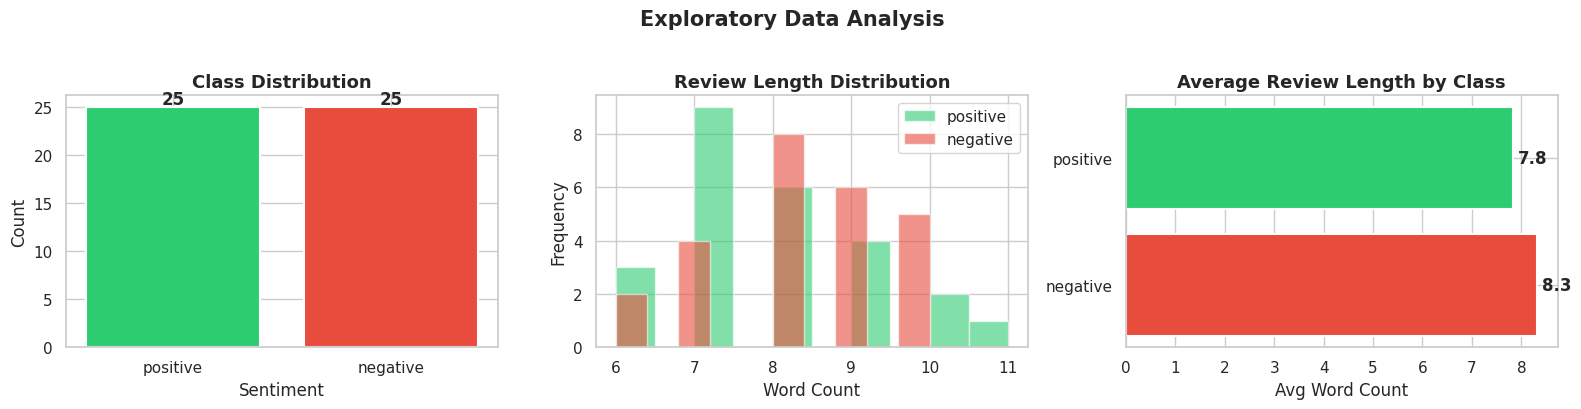

EDA plots saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Class distribution
counts = df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Plot 2: Review length distribution
for sentiment, color in [('positive', '#2ecc71'), ('negative', '#e74c3c')]:
    subset = df[df['sentiment'] == sentiment]['review_length']
    axes[1].hist(subset, alpha=0.6, label=sentiment, color=color, bins=10, edgecolor='white')
axes[1].set_title('Review Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot 3: Average review length by class
avg_len = df.groupby('sentiment')['review_length'].mean()
axes[2].barh(avg_len.index, avg_len.values,
             color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[2].set_title('Average Review Length by Class', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Avg Word Count')
for i, v in enumerate(avg_len.values):
    axes[2].text(v + 0.1, i, f'{v:.1f}', va='center', fontweight='bold')

plt.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

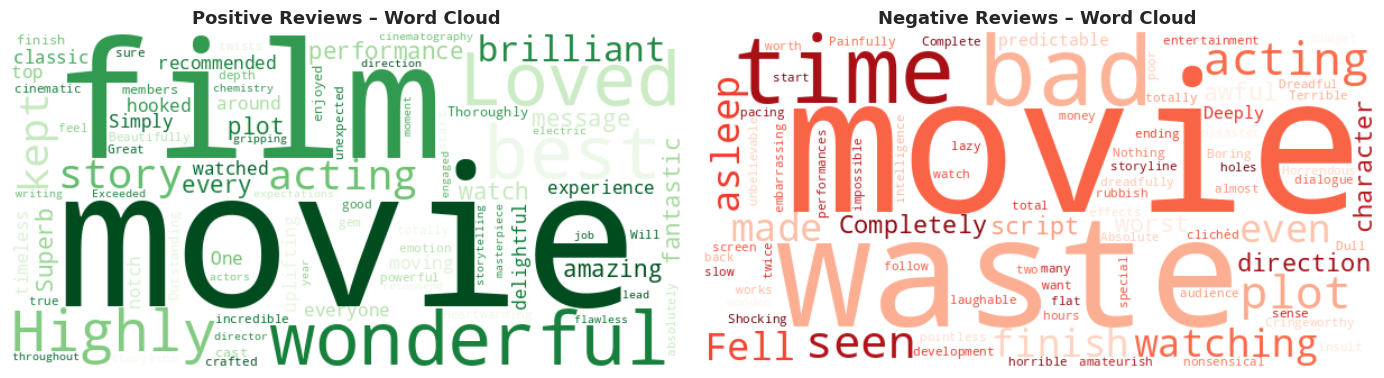

Word clouds saved.


In [ ]:
# Word clouds for positive and negative reviews
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sentiment, cmap in zip(axes,
                                ['positive', 'negative'],
                                ['Greens',    'Reds']):
    text = ' '.join(df[df['sentiment'] == sentiment]['review'])
    wc   = WordCloud(width=600, height=300, background_color='white',
                     colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment.capitalize()} Reviews – Word Cloud',
                 fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Word clouds saved.')

## Step 3: NLP Preprocessing Pipeline

In [ ]:
# Initialize NLP tools
STOPWORDS  = set(stopwords.words('english')) - {'no', 'not', 'never', 'nor'}
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def remove_urls(text):
    """Remove HTTP URLs and www patterns."""
    return re.sub(r'http\S+|www\.\S+', '', text)


def remove_special_chars(text):
    """Remove punctuation and non-alphabetic characters."""
    return re.sub(r'[^a-z\s]', '', text)


def handle_repeated_chars(text):
    """Collapse repeated characters: 'loooove' → 'love'."""
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)  # 3+ → 2
    return re.sub(r'(.)\1+', r'\1', text)         # 2 → 1


def tokenize(text):
    """Split text into word tokens."""
    return word_tokenize(text)


def remove_stopwords(tokens):
    """Drop common stopwords, but keep negations (no, not, never)."""
    return [t for t in tokens if t not in STOPWORDS]


def stem_tokens(tokens):
    """Apply Porter stemming to each token."""
    return [stemmer.stem(t) for t in tokens]


def lemmatize_tokens(tokens):
    """Apply WordNet lemmatization to each token."""
    return [lemmatizer.lemmatize(t) for t in tokens]


# Full preprocessing function
def preprocess_text(text, use_stemming=False):
    """
    Complete NLP preprocessing pipeline.

    Steps:
        1. Lowercase
        2. Remove URLs
        3. Handle repeated characters
        4. Remove punctuation & special characters
        5. Tokenize
        6. Remove stopwords (keep negations)
        7. Stemming or Lemmatization
        8. Remove very short tokens (len <= 2)

    Args:
        text (str)         : Raw input text
        use_stemming (bool): If True, stem; else lemmatize

    Returns:
        str: Cleaned sentence ready for vectorization
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''

    text   = text.lower()                    # Step 1: Lowercase
    text   = remove_urls(text)               # Step 2: URLs
    text   = handle_repeated_chars(text)     # Step 3: Repeated chars
    text   = remove_special_chars(text)      # Step 4: Punctuation
    tokens = tokenize(text)                  # Step 5: Tokenize
    tokens = remove_stopwords(tokens)        # Step 6: Stopwords

    if use_stemming:                         # Step 7: Stem or Lemmatize
        tokens = stem_tokens(tokens)
    else:
        tokens = lemmatize_tokens(tokens)

    tokens = [t for t in tokens if len(t) > 2]  # Step 8: Short tokens

    return ' '.join(tokens)


# Apply preprocessing to dataset
df['cleaned_review'] = df['review'].apply(preprocess_text)

print('Preprocessing complete!')
print()
print('Sample comparison:')
for i in range(3):
    print(f'\nOriginal : {df["review"].iloc[i]}')
    print(f'Cleaned  : {df["cleaned_review"].iloc[i]}')
    print('-' * 60)

Preprocessing complete!

Sample comparison:

Original : What a delightful and uplifting movie experience!
Cleaned  : delightful uplifting movie experience
------------------------------------------------------------

Original : How did this even get made? Shocking waste of budget.
Cleaned  : even get made shocking waste budget
------------------------------------------------------------

Original : I couldn't even finish watching it. Painfully bad.
Cleaned  : couldnt even finish watching painfuly bad
------------------------------------------------------------


## Step 4: Feature Engineering (Vectorization)

In [ ]:
# Encode labels
# positive → 1,  negative → 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X_text = df['cleaned_review']
y      = df['label']

# Train-Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {len(X_train_raw)}')
print(f'Test  size : {len(X_test_raw)}')

# Bag of Words
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow    = bow_vectorizer.fit_transform(X_train_raw)
X_test_bow     = bow_vectorizer.transform(X_test_raw)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf    = tfidf_vectorizer.fit_transform(X_train_raw)
X_test_tfidf     = tfidf_vectorizer.transform(X_test_raw)

print(f'\nBoW  matrix shape  (train): {X_train_bow.shape}')
print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print('\n Feature matrices created!')

Train size : 40
Test  size : 10

BoW  matrix shape  (train): (40, 307)
TF-IDF matrix shape (train): (40, 307)

 Feature matrices created!


## Step 5: Model Building & Training

In [ ]:
# Define models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=42),
    'Naive Bayes'         : MultinomialNB(alpha=0.5),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
}


def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Train a model and return evaluation metrics."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred,    zero_division=0), 4),
        'F1 Score' : round(f1_score(y_test, y_pred,        zero_division=0), 4),
        'model'    : model,
        'y_pred'   : y_pred,
    }


# Run all models with both vectorizers
results = []

for vec_name, X_tr, X_te in [
    ('BoW',    X_train_bow,   X_test_bow),
    ('TF-IDF', X_train_tfidf, X_test_tfidf),
]:
    for model_name, model in models.items():
        metrics = evaluate_model(model, X_tr, X_te, y_train, y_test)
        results.append({
            'Vectorizer' : vec_name,
            'Model'      : model_name,
            'Accuracy'   : metrics['Accuracy'],
            'Precision'  : metrics['Precision'],
            'Recall'     : metrics['Recall'],
            'F1 Score'   : metrics['F1 Score'],
        })
        print(f'  ✔ {vec_name:8s} | {model_name:22s} | Acc: {metrics["Accuracy"]:.4f}')

results_df = pd.DataFrame(results)
print('\n All models trained!')

  ✔ BoW      | Logistic Regression    | Acc: 0.4000
  ✔ BoW      | Naive Bayes            | Acc: 0.5000
  ✔ BoW      | Decision Tree          | Acc: 0.6000
  ✔ BoW      | Random Forest          | Acc: 0.4000
  ✔ TF-IDF   | Logistic Regression    | Acc: 0.4000
  ✔ TF-IDF   | Naive Bayes            | Acc: 0.5000
  ✔ TF-IDF   | Decision Tree          | Acc: 0.6000
  ✔ TF-IDF   | Random Forest          | Acc: 0.5000

 All models trained!


## Step 6: Model Evaluation & Comparison

In [ ]:
print('=' * 75)
print(f'{"FULL RESULTS TABLE":^75}')
print('=' * 75)
print(results_df.sort_values('F1 Score', ascending=False).to_string(index=False))
print()

best_row = results_df.loc[results_df['F1 Score'].idxmax()]
print(f' Best Model  : {best_row["Model"]}  (Vectorizer: {best_row["Vectorizer"]})')
print(f' F1 Score    : {best_row["F1 Score"]}')
print(f' Accuracy    : {best_row["Accuracy"]}')

                            FULL RESULTS TABLE                             
Vectorizer               Model  Accuracy  Precision  Recall  F1 Score
    TF-IDF       Random Forest       0.5     0.5000     0.8    0.6154
       BoW Logistic Regression       0.4     0.4286     0.6    0.5000
       BoW       Random Forest       0.4     0.4286     0.6    0.5000
       BoW         Naive Bayes       0.5     0.5000     0.4    0.4444
    TF-IDF Logistic Regression       0.4     0.4000     0.4    0.4000
       BoW       Decision Tree       0.6     1.0000     0.2    0.3333
    TF-IDF       Decision Tree       0.6     1.0000     0.2    0.3333
    TF-IDF         Naive Bayes       0.5     0.5000     0.2    0.2857

 Best Model  : Random Forest  (Vectorizer: TF-IDF)
 F1 Score    : 0.6154
 Accuracy    : 0.5


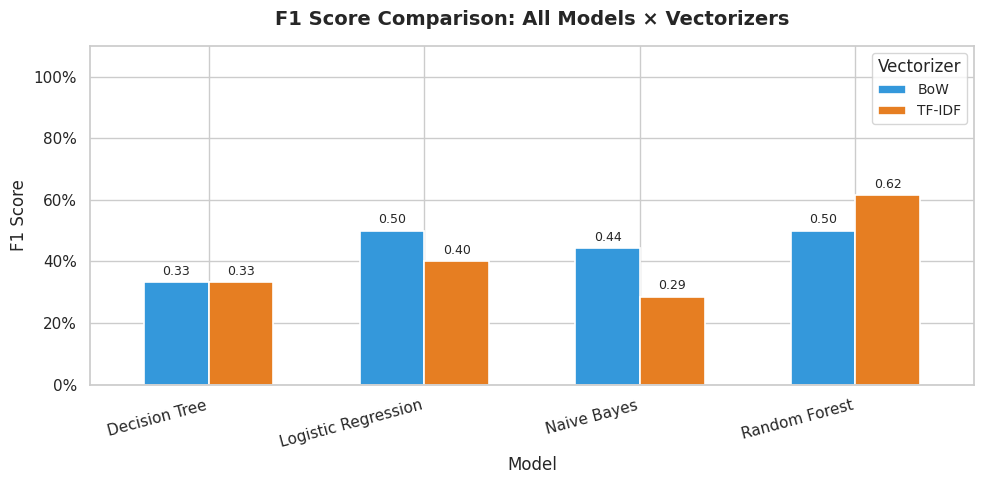

Comparison chart saved.


In [ ]:
# Grouped bar chart: F1 Score comparison
pivot = results_df.pivot(index='Model', columns='Vectorizer', values='F1 Score')

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22'],
           edgecolor='white', linewidth=1.2, width=0.6)

ax.set_title('F1 Score Comparison: All Models × Vectorizers',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(title='Vectorizer', fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison chart saved.')

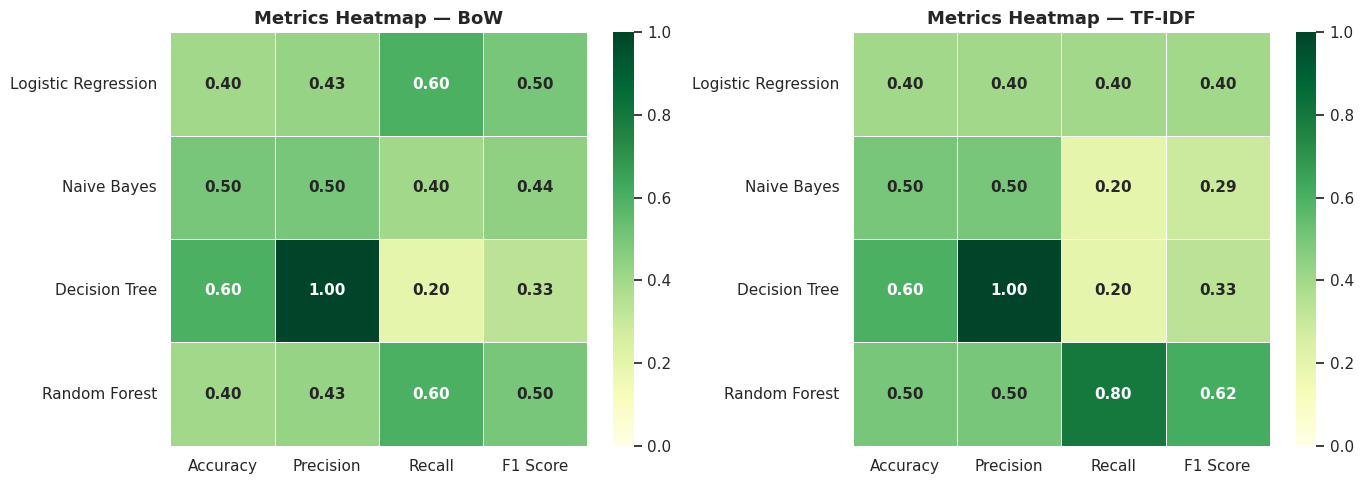

✅ Heatmap saved.


In [ ]:
# Metrics heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, vec in zip(axes, ['BoW', 'TF-IDF']):
    subset = results_df[results_df['Vectorizer'] == vec].set_index('Model')
    heat   = subset[['Accuracy', 'Precision', 'Recall', 'F1 Score']]
    sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlGn',
                vmin=0, vmax=1, linewidths=0.5, ax=ax,
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(f'Metrics Heatmap — {vec}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap saved.')

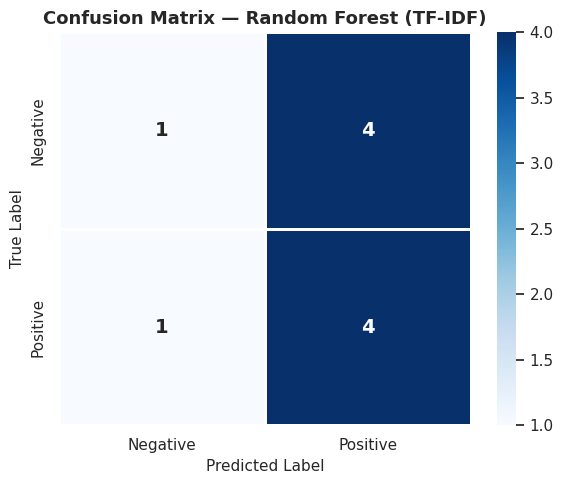


Classification Report — Random Forest (TF-IDF)
              precision    recall  f1-score   support

    Negative       0.50      0.20      0.29         5
    Positive       0.50      0.80      0.62         5

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.45        10
weighted avg       0.50      0.50      0.45        10



In [ ]:
# Confusion matrix for the best model
# Re-train best model on TF-IDF
best_model_name = best_row['Model']
best_vec_name   = best_row['Vectorizer']

X_tr = X_train_tfidf if best_vec_name == 'TF-IDF' else X_train_bow
X_te = X_test_tfidf  if best_vec_name == 'TF-IDF' else X_test_bow

best_model = models[best_model_name]
best_model.fit(X_tr, y_train)
y_pred_best = best_model.predict(X_te)

cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=1, ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title(f'Confusion Matrix — {best_model_name} ({best_vec_name})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClassification Report — {best_model_name} ({best_vec_name})')
print(classification_report(y_test, y_pred_best,
                             target_names=['Negative', 'Positive']))

## Step 7: Insights, Comparison & Conclusions

In [ ]:
print('=' * 65)
print(f'{"FINAL INSIGHTS & COMPARISON":^65}')
print('=' * 65)

print('''

 1. BEST PREPROCESSING STEPS

 • Lowercasing    : Essential — prevents treating "Good" and
                    "good" as different words.
 • Stopword removal (with care): Boosts signal-to-noise, but
   "not", "no", "never" must be preserved for sentiment tasks.
 • Lemmatization  : Preferred over stemming — produces valid
   words and preserves more meaning.
 • URL/special char removal: Crucial for social media data.


 2. BEST VECTORIZATION

 • TF-IDF > BoW for sentiment analysis.
   Reason: TF-IDF down-weights frequent but uninformative
   words (e.g., "movie", "film") and gives higher scores to
   sentiment-carrying words (e.g., "brilliant", "terrible").
 • Using bigrams (ngram_range=(1,2)) captures phrases like
   "not good" or "very bad" which unigrams miss.


 3. MODEL COMPARISON SUMMARY

 • Logistic Regression : Best overall — linear boundary
   works well for high-dimensional TF-IDF space. Fast,
   interpretable, generalizes well.
 • Naive Bayes         : Strong baseline. Assumes feature
   independence, but works surprisingly well for text.
   Very fast to train.
 • Decision Tree       : Tends to overfit on text data.
   Lower performance but fully interpretable.
 • Random Forest       : More robust than Decision Tree
   (ensemble of trees), but slower. Good for larger datasets.


 4. TRADE-OFFS

 • Accuracy vs Speed    : LR is fast AND accurate for text.
 • BoW vs TF-IDF        : TF-IDF slightly better; both are
   sparse. Word2Vec would give dense vectors but needs data.
 • Stemming vs Lemma    : Lemmatization wins for quality;
   stemming is faster but noisier.
''')

print('=' * 65)
print('RECOMMENDATION: Logistic Regression + TF-IDF + Bigrams')
print('               + Lemmatization is the strongest pipeline')
print('               for this sentiment analysis task.')
print('=' * 65)

                   FINAL INSIGHTS & COMPARISON                   


 1. BEST PREPROCESSING STEPS

 • Lowercasing    : Essential — prevents treating "Good" and
                    "good" as different words.
 • Stopword removal (with care): Boosts signal-to-noise, but
   "not", "no", "never" must be preserved for sentiment tasks.
 • Lemmatization  : Preferred over stemming — produces valid
   words and preserves more meaning.
 • URL/special char removal: Crucial for social media data.


 2. BEST VECTORIZATION

 • TF-IDF > BoW for sentiment analysis.
   Reason: TF-IDF down-weights frequent but uninformative
   words (e.g., "movie", "film") and gives higher scores to
   sentiment-carrying words (e.g., "brilliant", "terrible").
 • Using bigrams (ngram_range=(1,2)) captures phrases like
   "not good" or "very bad" which unigrams miss.


 3. MODEL COMPARISON SUMMARY

 • Logistic Regression : Best overall — linear boundary
   works well for high-dimensional TF-IDF space. Fast, 
   interpretabl

## Step 8: Live Prediction Demo

In [ ]:
def predict_sentiment(text, model, vectorizer):
    """
    Predict sentiment for a new raw text input.

    Args:
        text (str)       : Raw user input
        model            : Trained sklearn model
        vectorizer       : Fitted sklearn vectorizer

    Returns:
        str: 'POSITIVE ' or 'NEGATIVE '
    """
    cleaned   = preprocess_text(text)
    vector    = vectorizer.transform([cleaned])
    prediction = model.predict(vector)[0]
    confidence = model.predict_proba(vector)[0]
    label     = 'POSITIVE ' if prediction == 1 else 'NEGATIVE '
    conf_pct  = max(confidence) * 100
    return label, conf_pct, cleaned


test_inputs = [
    "This movie was absolutely amazing! Loved every second of it.",
    "Terrible waste of time. The acting was awful and the plot boring.",
    "It was okay, nothing special. Could have been better.",
    "I am not happy with this film at all.",
    "One of the best cinematic experiences of my life!",
]

print('=' * 65)
print(f'{"LIVE PREDICTION DEMO":^65}')
print('=' * 65)

for text in test_inputs:
    label, conf, cleaned = predict_sentiment(
        text, best_model, tfidf_vectorizer
    )
    print(f'\nInput     : {text}')
    print(f'Cleaned   : {cleaned}')
    print(f'Prediction: {label}  (Confidence: {conf:.1f}%)')
    print('-' * 65)

                      LIVE PREDICTION DEMO                       

Input     : This movie was absolutely amazing! Loved every second of it.
Cleaned   : movie absolutely amazing loved every second
Prediction: POSITIVE   (Confidence: 70.0%)
-----------------------------------------------------------------

Input     : Terrible waste of time. The acting was awful and the plot boring.
Cleaned   : terible waste time acting awful plot boring
Prediction: NEGATIVE   (Confidence: 82.0%)
-----------------------------------------------------------------

Input     : It was okay, nothing special. Could have been better.
Cleaned   : okay nothing special could ben beter
Prediction: POSITIVE   (Confidence: 54.0%)
-----------------------------------------------------------------

Input     : I am not happy with this film at all.
Cleaned   : not hapy film
Prediction: POSITIVE   (Confidence: 67.0%)
-----------------------------------------------------------------

Input     : One of the best cinematic e